In [1]:
import json
import os 
import glob
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader

In [2]:
class LazyDatasetList(Dataset):
    def __init__(self, data_files, transform=None, time_interval=timedelta(minutes=10)):
        self.data_files=data_files
        self.transform = transform
        self.time_interval = time_interval

        # Build a mapping from datetime -> filepath
        self.time_format = "%Y%m%d%H%M"
        self.time_to_file = {}
        for f in self.data_files:
            ts = os.path.splitext(os.path.basename(f))[0]
            try:
                dt = datetime.strptime(ts, self.time_format)
                self.time_to_file[dt] = f
            except ValueError:
                continue  # Skip malformed filenames

        # Sort the datetimes
        sorted_times = sorted(self.time_to_file.keys())

        # Build valid pairs [t-interval, t]
        self.time_list = []
        for t in sorted_times:
            next_t = t - self.time_interval #t-1
            next_t_2 = next_t - self.time_interval #t-2
            next_t_3 = next_t_2 - self.time_interval #t-3
            if next_t in self.time_to_file and next_t_2 in self.time_to_file and next_t_3 in self.time_to_file:
                self.time_list.append((self.time_to_file[t], 
                                       self.time_to_file[next_t], 
                                       self.time_to_file[next_t_2], 
                                       self.time_to_file[next_t_3]))

    def __len__(self):
        return len(self.time_list)

    def __getitem__(self, idx):
        f_t, f_t_1, f_t_2, f_t_3 = self.time_list[idx]
        full_str = f'{os.path.basename(f_t_3)},{os.path.basename(f_t_2)},{os.path.basename(f_t_1)},{os.path.basename(f_t)}'
        # Load data
        data_list = []
        for t_step in [f_t_3, f_t_2, f_t_1, f_t]:
            data=torch.load(t_step).unsqueeze(0)
            if self.transform:
                data = self.transform(data)
            data_list.append(data)
        data=torch.cat(data_list, dim=0)

        return {'data': data, 'source': full_str}

In [3]:
class MinMaxToMinusOneOne:
    def __init__(self, min_vals, max_vals, ):
        self.min_vals = torch.tensor(min_vals).view(-1, 1, 1)
        self.max_vals = torch.tensor(max_vals).view(-1, 1, 1)
        
    def __call__(self, x):
        # x: [C, H, W]
        x = (x - self.min_vals) / (self.max_vals - self.min_vals + 1e-6)  # → [0, 1]
        return x * 2.0 - 1.0  # → [-1, 1]

In [4]:
input_dir='/scratch/nf33/cd3022/pyearth'

# Load saved min/max
with open(os.path.join(input_dir, 'min_max.json'), 'r') as f:
    stats = json.load(f)
    min_vals, max_vals = torch.tensor(stats['min'], dtype=torch.float32), torch.tensor(stats['max'], dtype=torch.float32)

data_files=sorted(glob.glob(os.path.join(input_dir, '*.pt')))
train_dataset = LazyDatasetList(data_files, transform=MinMaxToMinusOneOne(min_vals, max_vals))

/jobfs/163181289.gadi-pbs/ipykernel_3729087/3393117095.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.min_vals = torch.tensor(min_vals).view(-1, 1, 1)
/jobfs/163181289.gadi-pbs/ipykernel_3729087/3393117095.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.max_vals = torch.tensor(max_vals).view(-1, 1, 1)


In [5]:
loader = DataLoader(train_dataset, batch_size=2, shuffle=False, num_workers=2)

In [6]:
data_sample = next(iter(loader))
data_sample['data'].shape #B, C, H, W

torch.Size([2, 4, 64, 64])

In [7]:
len(data_sample['source'])

2

In [8]:
data_sample['source']

['202101010000.pt,202101010010.pt,202101010020.pt,202101010030.pt',
 '202101010010.pt,202101010020.pt,202101010030.pt,202101010040.pt']

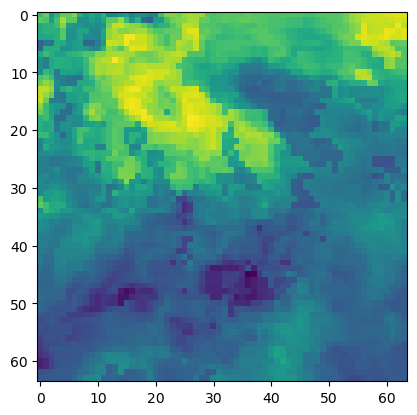

In [9]:
#plot original data w/o norm
plt_dataset = LazyDatasetList(data_files)
loader = DataLoader(plt_dataset, batch_size=2, shuffle=False, num_workers=2)
data_sample = next(iter(loader))
plt.imshow(data_sample['data'][0, 0, :, :])

In [10]:
data_sample['data'][0, 0, :, :]

tensor([[514.6800, 579.3400, 400.1500,  ..., 700.3100, 710.6900, 702.9500],
        [562.8800, 543.2800, 419.7200,  ..., 685.2400, 693.5600, 685.7100],
        [464.9400, 483.6200, 487.3300,  ..., 662.4600, 717.6800, 662.1800],
        ...,
        [ 92.8100, 115.7400, 176.2900,  ..., 227.0900, 224.3600, 227.1500],
        [208.9300, 214.2600, 223.5300,  ..., 228.3400, 224.3600, 227.1500],
        [226.6900, 226.1600, 237.9500,  ..., 240.8500, 240.5600, 233.1400]],
       dtype=torch.float64)

In [11]:
#check data equality based on source labels
original = torch.load('/scratch/nf33/cd3022/pyearth/202101010000.pt')
torch.equal(original, data_sample['data'][0, 0, :, :])

True

In [13]:
from dataclasses import dataclass
from torchvision import transforms
import torch
from diffusers import UNet2DModel
from diffusers import DDPMScheduler
import torch.nn.functional as F
from diffusers.optimization import get_cosine_schedule_with_warmup
from diffusers import DDPMPipeline
import os
from accelerate import Accelerator
from tqdm.auto import tqdm
from accelerate import notebook_launcher

In [16]:
@dataclass
class TrainingConfig:
    in_channels=4
    out_channels=1
    image_size = 64  # the generated image resolution
    train_batch_size = 2
    num_epochs = 2500
    gradient_accumulation_steps = 100
    learning_rate = 1e-4
    lr_warmup_steps = 600 #5-10% of total
    save_model_epochs = 500
    mixed_precision = "bf16"  # `no` for float32, `fp16` for automatic mixed precision
    output_dir = "/scratch/nf33/cd3022/pyearth/model"  # the model name locally and on the HF Hub
    resume_from_checkpoint = False
    #push_to_hub = True  # whether to upload the saved model to the HF Hub
    #hub_model_id = "<your-username>/<my-awesome-model>"  # the name of the repository to create on the HF Hub
    #hub_private_repo = None
    overwrite_output_dir = True  # overwrite the old model when re-running the notebook
    seed = 0

In [22]:
def train_loop(config, 
               model, 
               noise_scheduler, 
               optimizer, 
               train_dataloader, 
               lr_scheduler):

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    # Initialize accelerator and tensorboard logging
    accelerator = Accelerator(
        mixed_precision=config.mixed_precision,
        gradient_accumulation_steps=config.gradient_accumulation_steps,
        log_with="tensorboard",
        project_dir=os.path.join(config.output_dir, "logs"),
    )

    if accelerator.is_main_process:
        if config.output_dir is not None:
            os.makedirs(config.output_dir, exist_ok=True)
        accelerator.init_trackers("train_example")
        
    # Prepare everything
    # There is no specific order to remember, you just need to unpack the
    # objects in the same order you gave them to the prepare method.
    model, optimizer, train_dataloader, lr_scheduler = accelerator.prepare(
        model, optimizer, train_dataloader, lr_scheduler
    )

    # checkpointing
    checkpt_dir = os.path.join(os.path.join(config.output_dir,  'checkpoint'))
    if not os.path.exists(checkpt_dir):
        os.makedirs(checkpt_dir, exist_ok=True)

    accelerator.register_for_checkpointing(lr_scheduler)

    global_step = 0

    # Now you train the model
    for epoch in range(config.num_epochs):
        progress_bar = tqdm(total=len(train_dataloader), disable=not accelerator.is_local_main_process)
        progress_bar.set_description(f"Epoch {epoch}")

        #layer 0-2: conditions layer 2-4: targets
        for step, batch in enumerate(train_dataloader):
            condition_images = batch['data'][:, 0:3, :, :].detach().to(torch.bfloat16).to(device) 
            clean_images = batch['data'][:, 3:4, :, :].detach().to(torch.bfloat16).to(device) 

            # Sample noise to add to the images
            noise = torch.randn(clean_images.shape, device=clean_images.device)
            bs = clean_images.shape[0]

            # Sample a random timestep for each image
            timesteps = torch.randint(
                0, noise_scheduler.config.num_train_timesteps, (bs,), device=clean_images.device,
                dtype=torch.int64
            ).to(device)

            # Add noise to the clean images according to the noise magnitude at each timestep
            # (this is the forward diffusion process)
            noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

            with accelerator.accumulate(model):
                # Predict the noise residual

                x_t = torch.cat([noisy_images, condition_images], dim=1)  
                noise_pred = model(x_t, timesteps, return_dict=False)[0]
                loss = F.mse_loss(noise_pred, noise)

                accelerator.backward(loss)

                if accelerator.sync_gradients:
                    accelerator.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                lr_scheduler.step()
                optimizer.zero_grad()

            progress_bar.update(1)
            logs = {"loss": loss.detach().item(), "lr": lr_scheduler.get_last_lr()[0], "step": global_step}
            progress_bar.set_postfix(**logs)
            accelerator.log(logs, step=global_step)
            global_step += 1

        # After each epoch you optionally sample some demo images with evaluate() and save the model
        if accelerator.is_main_process:
            pipeline = DDPMPipeline(unet=accelerator.unwrap_model(model), scheduler=noise_scheduler)

            #if (epoch + 1) % config.save_image_epochs == 0 or epoch == config.num_epochs - 1:
            #    evaluate(config, epoch, pipeline)

            if (epoch + 1) % config.save_model_epochs == 0 or epoch == config.num_epochs - 1:
                epoch_ckpt_dir = os.path.join(config.output_dir, f"checkpoint/epoch_{epoch+10:04d}")
                accelerator.save_state(epoch_ckpt_dir)
                pipeline.save_pretrained(epoch_ckpt_dir)

In [23]:
config = TrainingConfig()
# Autodetect GPU and use if possible
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
input_dir='/scratch/nf33/cd3022/pyearth'

# Load saved min/max
with open('/scratch/nf33/cd3022/pyearth/min_max.json', 'r') as f:
    stats = json.load(f)
    min_vals, max_vals = torch.tensor(stats['min'], dtype=torch.bfloat16), torch.tensor(stats['max'], dtype=torch.bfloat16)
    
data_files=glob.glob(os.path.join(input_dir, '*.pt'))
dataset = LazyDatasetList(data_files, transform=MinMaxToMinusOneOne(min_vals, max_vals))
train_dataloader = torch.utils.data.DataLoader(dataset, 
                                                batch_size=config.train_batch_size, 
                                                shuffle=True, 
                                                )

model = UNet2DModel(
    sample_size=config.image_size,  # the target image resolution
    in_channels=config.in_channels,  # the number of input channels, 3 for RGB images
    out_channels=config.out_channels,  # the number of output channels
    layers_per_block=2,  # how many ResNet layers to use per UNet block
    block_out_channels=(32, 64, 128, 256),  # the number of output channels for each UNet block
    down_block_types=(
        "DownBlock2D",  
        "DownBlock2D",
        "AttnDownBlock2D",
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D", 
        "AttnUpBlock2D", 
        "UpBlock2D",
        "UpBlock2D",

    ),
).to(device)

noise_scheduler = DDPMScheduler(num_train_timesteps=1000)
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)
lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=config.lr_warmup_steps,
    num_training_steps=(len(train_dataloader) * config.num_epochs),
)
args = (config, model, noise_scheduler, optimizer, train_dataloader, lr_scheduler)

/jobfs/163181289.gadi-pbs/ipykernel_3729087/3393117095.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.min_vals = torch.tensor(min_vals).view(-1, 1, 1)
/jobfs/163181289.gadi-pbs/ipykernel_3729087/3393117095.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.max_vals = torch.tensor(max_vals).view(-1, 1, 1)


In [ ]:
%%capture
#start train
notebook_launcher(train_loop, args, num_processes=1)